In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
df=pd.read_csv("telecom_churn_dataset.csv")
df

,customer_id,age,tenure_months,monthly_recharge,data_usage_gb,num_complaints,plan_type,region,avg_call_drops,churned
0,1,19,66,858.29,7.82,0,prepaid,south,4,0
1,2,47,38,504.74,46.86,4,prepaid,north,11,1
2,3,45,82,685.22,27.99,7,prepaid,north,9,0
3,4,36,76,369.37,53.46,1,prepaid,north,7,0
4,5,18,65,340.26,49.43,3,postpaid,north,0,0
...,...,...,...,...,...,...,...,...,...,...
5995,5996,64,71,281.06,6.08,2,postpaid,east,1,0
5996,5997,44,61,211.85,0.69,3,prepaid,east,1,0
5997,5998,67,62,516.98,26.18,0,prepaid,east,2,0
5998,5999,54,7,721.11,26.23,4,prepaid,north,8,1


In [2]:
df.shape

(6000, 10)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       6000 non-null   int64  
 1   age               6000 non-null   int64  
 2   tenure_months     6000 non-null   int64  
 3   monthly_recharge  6000 non-null   float64
 4   data_usage_gb     6000 non-null   float64
 5   num_complaints    6000 non-null   int64  
 6   plan_type         6000 non-null   str    
 7   region            6000 non-null   str    
 8   avg_call_drops    6000 non-null   int64  
 9   churned           6000 non-null   int64  
dtypes: float64(2), int64(6), str(2)
memory usage: 538.9 KB


In [4]:
df.describe()

,customer_id,age,tenure_months,monthly_recharge,data_usage_gb,num_complaints,avg_call_drops,churned
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,43.082167,41.777667,546.770443,30.621887,3.481667,6.913667,0.500000
std,1732.195139,14.943604,24.322161,259.477233,17.086192,2.292206,4.321226,0.500042
min,1.000000,18.000000,0.000000,99.230000,0.530000,0.000000,0.000000,0.000000
25%,1500.750000,30.000000,21.000000,325.475000,15.687500,1.000000,3.000000,0.000000
50%,3000.500000,43.000000,42.000000,545.800000,30.710000,3.000000,7.000000,0.500000
75%,4500.250000,56.000000,63.000000,769.645000,45.685000,6.000000,11.000000,1.000000
max,6000.000000,69.000000,83.000000,998.770000,59.990000,7.000000,14.000000,1.000000


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

customer_id         0
age                 0
tenure_months       0
monthly_recharge    0
data_usage_gb       0
num_complaints      0
plan_type           0
region              0
avg_call_drops      0
churned             0
dtype: int64

In [7]:
df['churned'].value_counts()

churned
0    3000
1    3000
Name: count, dtype: int64

In [8]:
df.drop(columns=["customer_id"],inplace=True)

In [9]:
# one hot encode the categorical columns like the bank churn notebook did
df=pd.get_dummies(df,columns=['plan_type','region'],drop_first=True)
df.head()

,age,tenure_months,monthly_recharge,data_usage_gb,num_complaints,avg_call_drops,churned,plan_type_prepaid,region_north,region_south,region_west
0,19,66,858.29,7.82,0,4,0,True,False,True,False
1,47,38,504.74,46.86,4,11,1,True,True,False,False
2,45,82,685.22,27.99,7,9,0,True,True,False,False
3,36,76,369.37,53.46,1,7,0,True,True,False,False
4,18,65,340.26,49.43,3,0,0,False,True,False,False


In [10]:
X=df.drop(columns=['churned'])
y=df['churned']

In [11]:
from sklearn.model_selection import train_test_split
train_X,test_X,train_y,test_y=train_test_split(X,y,test_size=0.3,random_state=123)

In [12]:
train_X.shape[1]

10

In [13]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
train_X=sc.fit_transform(train_X)
test_X=sc.transform(test_X)

In [14]:
## ANN MODEL (SIGMOID OUTPUT)
from keras.models import Sequential
from keras.layers import Dense

model=Sequential()
model.add(Dense(units=11,kernel_initializer="uniform",activation="relu",input_dim=train_X.shape[1]))
model.add(Dense(units=6,kernel_initializer="uniform",activation="relu"))
model.add(Dense(units=4,kernel_initializer="uniform",activation="relu"))
model.add(Dense(units=1,kernel_initializer="uniform",activation="sigmoid"))

I0000 00:00:1782229595.066247 1196411 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782229598.204174 1196411 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2068 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           121 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226 (904.00 B)

 Trainable params: 226 (904.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [17]:
history=model.fit(train_X,train_y,batch_size=10,epochs=15,validation_split=0.1)

Epoch 1/15


I0000 00:00:1782229600.608728 1196516 service.cc:153] XLA service 0x799678031c00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782229600.608749 1196516 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.2)
I0000 00:00:1782229600.651676 1196516 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


I0000 00:00:1782229600.917984 1196516 cuda_dnn.cc:461] Loaded cuDNN version 92302
I0000 00:00:1782229600.930213 1196516 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1525__.9


  1/378 ━━━━━━━━━━━━━━━━━━━━ 18:17 3s/step - accuracy: 0.3000 - loss: 0.6931

 46/378 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4414 - loss: 0.6932  

...

223/378 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8265 - loss: 0.3844

263/378 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8253 - loss: 0.3860

306/378 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8245 - loss: 0.3872

343/378 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8241 - loss: 0.3878

378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8206 - loss: 0.3943 - val_accuracy: 0.7929 - val_loss: 0.4236


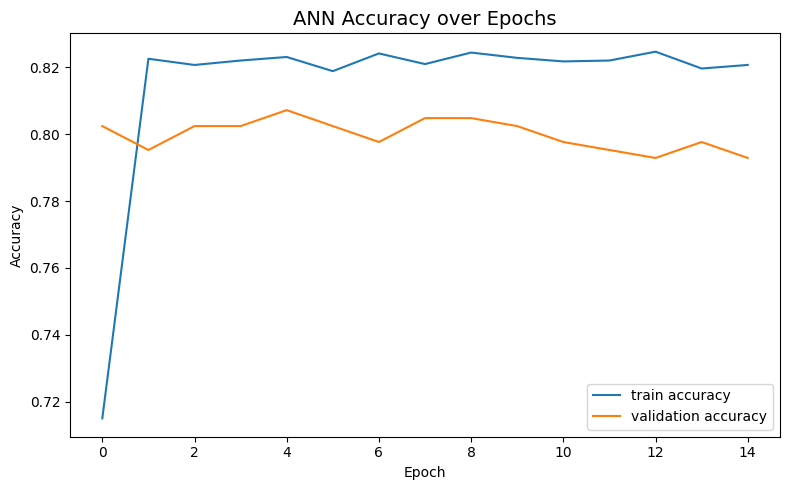

In [18]:
# plot training vs validation accuracy across epochs
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"],label="train accuracy")
plt.plot(history.history["val_accuracy"],label="validation accuracy")
plt.title("ANN Accuracy over Epochs",fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
prob_test=model.predict(test_X)  # probability
prob_test

 1/57 ━━━━━━━━━━━━━━━━━━━━ 31s 555ms/step

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step   

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


array([[0.31163484],
       [0.85233426],
       [0.91965157],
       ...,
       [0.886377  ],
       [0.7935239 ],
       [0.06182034]], shape=(1800, 1), dtype=float32)

In [20]:
from sklearn import metrics
y_test_pred=np.where(prob_test>0.5,1,0)
print(metrics.classification_report(test_y,y_test_pred))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81       889
           1       0.81      0.83      0.82       911

    accuracy                           0.82      1800
   macro avg       0.82      0.82      0.82      1800
weighted avg       0.82      0.82      0.82      1800

